# Phase 4 — Baselines and Ridge

First modeling pass. Establishes two baselines (global mean, hour-of-day mean) plus a Ridge regression with `log1p` target transformation. Each model is evaluated two ways: a chronological `TimeSeriesSplit(5)` (forecast future months) and a day-of-month holdout (train on days 1-15, validate on the latest labeled days 16-19), which mirrors the dataset's own day-of-month train/test structure. All four metrics (RMSLE, RMSE, MAE, R²) are reported together. The tables and figures below are sourced from `reports/metrics.json` produced by `scripts/train_model.py`. This notebook is diagnostic, not part of the runtime pipeline.

## Setup and data load

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit

from bike_sharing.config import load_config
from bike_sharing.models import get_model
from bike_sharing.train import fit_and_cv

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "config" / "config.yaml").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate config/config.yaml above cwd.")
    PROJECT_ROOT = PROJECT_ROOT.parent

CFG = load_config(PROJECT_ROOT / "config" / "config.yaml")
FIG_DIR = Path(CFG["paths"]["reports_dir"]) / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
METRICS_PATH = Path(CFG["paths"]["reports_dir"]) / "metrics.json"

sns.set_theme(context="notebook", style="whitegrid")
print("metrics file:", METRICS_PATH)


metrics file: /Users/gokturkberkekorkut/bike-sharing-demand-forecasting/reports/metrics.json


In [2]:
train_path = Path(CFG["paths"]["processed_dir"]) / "train.parquet"
df = pd.read_parquet(train_path).sort_values("datetime").reset_index(drop=True)
y = df["count"].to_numpy(float)
datetime = df["datetime"]
X = df.drop(columns=["count", "datetime"])
print("train rows:", len(df), " feature columns:", X.shape[1])


train rows: 10886  feature columns: 21


## 1. Cross-validation folds

`TimeSeriesSplit` produces five expanding training windows, each followed by a non-overlapping validation window. Earlier folds have less training data; the first fold is the smallest and the least representative of the full data.

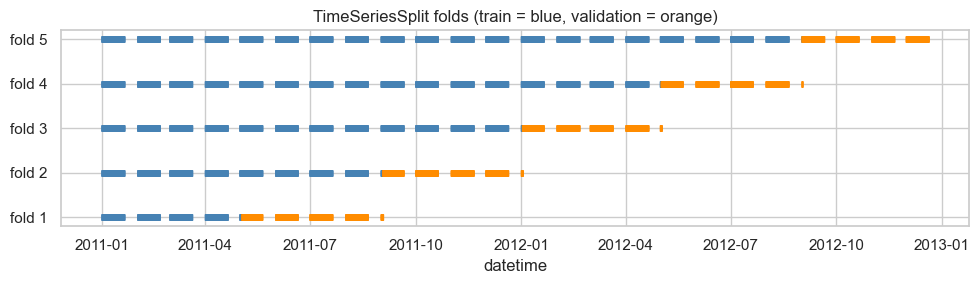

In [3]:
# Visualize the TimeSeriesSplit fold boundaries. Each fold's training
# window grows; each validation window is the next time chunk.
splitter = TimeSeriesSplit(n_splits=CFG["cv"]["n_splits"])
fig, ax = plt.subplots(figsize=(10, 3))
for i, (tr, va) in enumerate(splitter.split(X)):
    ax.plot(datetime.iloc[tr], np.full(len(tr), i), "|", color="steelblue", markersize=4)
    ax.plot(datetime.iloc[va], np.full(len(va), i), "|", color="darkorange", markersize=4)
ax.set_yticks(range(CFG["cv"]["n_splits"]))
ax.set_yticklabels([f"fold {i+1}" for i in range(CFG["cv"]["n_splits"])])
ax.set_title("TimeSeriesSplit folds (train = blue, validation = orange)")
ax.set_xlabel("datetime")
fig.tight_layout()
fig.savefig(FIG_DIR / "09_cv_folds.png", dpi=120, bbox_inches="tight")
plt.show()


## 2. Metric comparison (CV vs day-of-month holdout)

All four metrics (RMSLE, RMSE, MAE, R²) are read together; none is the single deciding score. RMSLE is shown because the target is right-skewed. Both validation views appear: `cv_rmsle` is the mean over the five chronological folds, `holdout_rmsle` is the single day-of-month holdout score. The holdout is the more realistic generalization estimate because it matches how the dataset itself is split by day-of-month. Lower is better; table sorted by holdout RMSLE.

In [4]:
# Load the metrics table written by scripts/train_model.py and compare.
# Each model entry has two validation views: chronological CV ("cv") and
# the day-of-month holdout ("day_of_month_holdout").
metrics = json.loads(METRICS_PATH.read_text())
rows = []
for name, summary in metrics.items():
    cv = summary["cv"]["mean"]
    holdout = summary["day_of_month_holdout"]["metrics"]
    rows.append({
        "model": name,
        "cv_rmsle": cv["rmsle"],
        "cv_rmsle_std": summary["cv"]["std"]["rmsle"],
        "holdout_rmsle": holdout["rmsle"],
        "holdout_rmse": holdout["rmse"],
        "holdout_mae": holdout["mae"],
        "holdout_r2": holdout["r2"],
    })
table = (
    pd.DataFrame(rows)
    .set_index("model")
    .sort_values("holdout_rmsle")
)
table.round(3)


,cv_rmsle,cv_rmsle_std,holdout_rmsle,holdout_rmse,holdout_mae,holdout_r2
model,,,,,,
xgboost,0.463,0.132,0.306,47.540,28.000,0.933
gradient_boosting,0.453,0.118,0.312,51.660,31.047,0.920
random_forest,0.515,0.141,0.328,51.805,29.909,0.920
ridge,0.806,0.110,0.718,140.811,89.064,0.408
hourly_mean_baseline,0.739,0.098,0.755,125.884,86.065,0.527
mean_baseline,1.402,0.071,1.531,183.077,142.644,-0.001


## 3. Per-fold RMSLE

Per-fold scores expose instabilities that an average can hide. Single-fold pathologies often signal a feature distribution shift between train and validation. A clean linear baseline should trend smoothly from fold 1 to fold 5; sharp spikes earn an investigation.

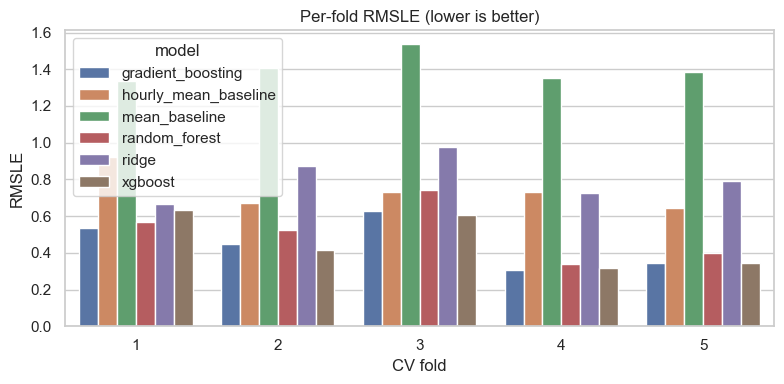

In [5]:
# Per-fold RMSLE for the three models. Helps spot single-fold pathologies.
fold_records = []
for name, summary in metrics.items():
    for i, f in enumerate(summary["cv"]["folds"]):
        fold_records.append({"model": name, "fold": i + 1, "rmsle": f["rmsle"]})
fold_df = pd.DataFrame(fold_records)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=fold_df, x="fold", y="rmsle", hue="model", ax=ax)
ax.set_title("Per-fold RMSLE (lower is better)")
ax.set_xlabel("CV fold")
ax.set_ylabel("RMSLE")
ax.legend(title="model")
fig.tight_layout()
fig.savefig(FIG_DIR / "10_per_fold_rmsle.png", dpi=120, bbox_inches="tight")
plt.show()


## 4. Ridge out-of-sample residuals by hour

First-harmonic cyclic features (`hour_sin`, `hour_cos`) plus `workingday` cannot represent two different hourly curves at once. The feature experiment (`docs/experiments/2026-06-01_leakage-safe-feature-sweep.md`) added a second hour harmonic and workingday-gated cyclic terms - a linear-safe encoding of the `hour x workingday` interaction, now part of the production feature set - so the Ridge below carries them. Fit on days 1-15 and scored on the held-out days 16-19, its residuals are much flatter across the hour axis than the first-harmonic version was, which is why Ridge now edges past the hourly-mean baseline. The structure that remains is what the non-linear trees still capture better.

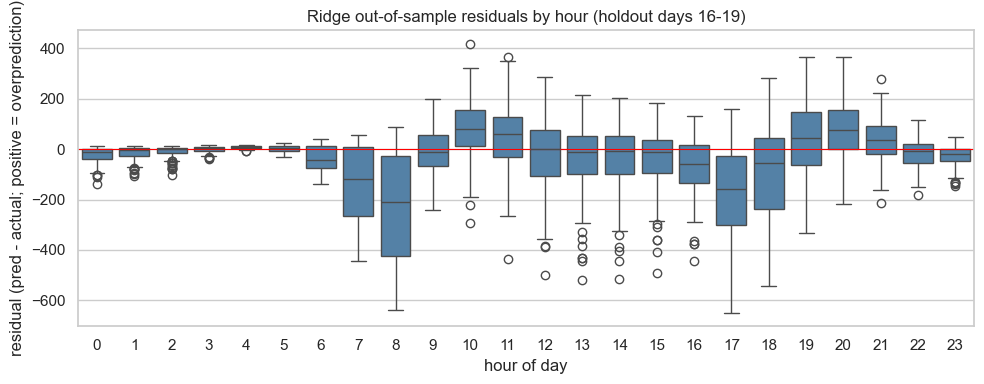

In [6]:
# Out-of-sample residuals: fit Ridge on the early day-of-month rows
# (1-15) and compute residuals on the held-out days (16-19) it never
# saw. This is a genuine generalization view, not in-sample diagnostics.
from bike_sharing.train import day_of_month_holdout_split

train_idx, holdout_idx = day_of_month_holdout_split(datetime)
ridge = get_model("ridge", CFG).fit(X.iloc[train_idx], y[train_idx])
holdout_pred = ridge.predict(X.iloc[holdout_idx])

resid_df = pd.DataFrame({
    "hour": X.iloc[holdout_idx]["hour"].to_numpy(),
    "residual": holdout_pred - y[holdout_idx],
})

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=resid_df, x="hour", y="residual", color="steelblue", ax=ax)
ax.axhline(0, color="red", linewidth=0.8)
ax.set_title("Ridge out-of-sample residuals by hour (holdout days 16-19)")
ax.set_xlabel("hour of day")
ax.set_ylabel("residual (pred - actual; positive = overprediction)")
fig.tight_layout()
fig.savefig(FIG_DIR / "11_ridge_residuals_by_hour.png", dpi=120, bbox_inches="tight")
plt.show()


## Findings (feed into Phase 4 review and Phase 5 trees)

- With the engineered cyclic feature set, `ridge` now narrowly beats `hourly_mean_baseline` on the day-of-month holdout (RMSLE 0.718 vs 0.755) and on CV. Before the feature experiment, with first-harmonic features only, it lost to the per-hour mean - the bimodal commuter shape, not linearity itself, was the binding constraint.
- Both still trail the trees by a wide margin (RMSLE ~0.31): the linear model's gain is a useful explainability result, not a competitive one. A per-hour mean remains a remarkably strong, interpretable benchmark.
- The Ridge ColumnTransformer drops the raw ordinal time columns (`hour`, `month`, `dayofweek`, `year`); only cyclic encodings (now including the second-harmonic and workingday-gated terms) and one-hot `season`/`weather` are exposed to the linear model. This prevented an earlier numerical blow-up in fold 1 where train-month range (1-5) underrepresented val-month range (up to 9).
- The tree models (Phase 5) use the full feature set including raw ordinals; trees are scale-invariant and benefit from the raw representation.
- The `hour x workingday` interaction and second-harmonic Fourier features flagged here as candidates were taken up in `docs/experiments/2026-06-01_leakage-safe-feature-sweep.md`; the workingday-gated cyclic + second-harmonic group was promoted, the rest (peaks, environmental products, year flag) were not.
- Interpretation for the report: the dominant demand signal is *temporal* (hour-of-day, split by working vs non-working day), which is why a trivial hour-of-day average is hard to beat. Weather and seasonal (environmental) effects are secondary and are where the linear model still adds value over the per-hour mean. These results map directly onto the proposal's temporal and environmental-impact questions and will be consolidated in the Phase 7 results report.